# Automatic Differentiation Using JAX

A third way to compute derivatives — **automatic differentiation (AD)**. Unlike symbolic (SymPy) or numerical (NumPy finite differences), AD gives **exact** results by systematically applying the chain rule under the hood.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

## How Does AD Work?

AD breaks a function into elementary operations (+, ×, sin, exp, …) and applies the **chain rule** at each step. For $y = f(g(x))$:

$$\frac{dy}{dx} = \frac{dy}{dg} \cdot \frac{dg}{dx}$$

There are two modes:
- **Forward mode**: propagates derivatives input → output (good for few inputs, many outputs)
- **Reverse mode** (backpropagation): propagates output → input (good for many inputs, few outputs — this is what deep learning uses)

### Comparison of Approaches

| Method | Accuracy | Key Trade-off |
|--------|----------|---------------|
| Symbolic (SymPy) | Exact formula | Slow for complex expressions |
| Numerical (NumPy) | Approximate | Must choose step size $h$ |
| **Automatic (JAX)** | **Exact (to float precision)** | **Need to use JAX arrays** |

## `jax.grad()` — The Core Function

`jax.grad(f)` returns a **new function** that computes $f'(x)$.

In [2]:
# f(x) = x²  →  f'(x) = 2x
def f(x):
    return x**2

f_prime = jax.grad(f)

for x in [1.0, 2.0, 3.0, 4.0, 5.0]:
    print(f"f'({x}) = {f_prime(x):.4f}  (exact: {2*x:.4f})")

f'(1.0) = 2.0000  (exact: 2.0000)
f'(2.0) = 4.0000  (exact: 4.0000)
f'(3.0) = 6.0000  (exact: 6.0000)
f'(4.0) = 8.0000  (exact: 8.0000)
f'(5.0) = 10.0000  (exact: 10.0000)


## Example: $f(x) = \sin(x)$

In [3]:
# f(x) = sin(x)  →  f'(x) = cos(x)
grad_sin = jax.grad(jnp.sin)

x = jnp.pi / 4
print(f"JAX:    f'(π/4) = {float(grad_sin(x)):.12f}")
print(f"Exact:  cos(π/4) = {float(jnp.cos(x)):.12f}")
print(f"Error:  {abs(float(grad_sin(x)) - float(jnp.cos(x))):.2e}")

JAX:    f'(π/4) = 0.707106769085
Exact:  cos(π/4) = 0.707106769085
Error:  0.00e+00


## Chain Rule: Composite Functions

JAX handles the chain rule automatically. For $f(x) = \sin(x^2)$, the derivative is $f'(x) = 2x\cos(x^2)$.

In [4]:
def f(x):
    return jnp.sin(x**2)

f_prime = jax.grad(f)

for x in [0.5, 1.0, 1.5, 2.0]:
    jax_val = f_prime(jnp.array(x))
    exact = 2 * x * jnp.cos(x**2)
    print(f"x={x:.1f}:  JAX={jax_val:.8f}  exact={exact:.8f}  error={abs(jax_val - exact):.2e}")

x=0.5:  JAX=0.96891242  exact=0.96891242  error=0.00e+00
x=1.0:  JAX=1.08060455  exact=1.08060455  error=0.00e+00
x=1.5:  JAX=-1.88452101  exact=-1.88452101  error=0.00e+00
x=2.0:  JAX=-2.61457443  exact=-2.61457443  error=0.00e+00


## Gradients of Vector Inputs

For $f(\mathbf{x}) = \|\mathbf{x}\|^2 = x_1^2 + x_2^2 + x_3^2$, the gradient is $\nabla f = [2x_1, 2x_2, 2x_3]$.

In [5]:
def f(x):
    return jnp.sum(x**2)

grad_f = jax.grad(f)

x = jnp.array([1.0, 2.0, 3.0])
print(f"x        = {x}")
print(f"JAX grad = {grad_f(x)}")
print(f"Exact    = {2 * x}")

x        = [1. 2. 3.]
JAX grad = [2. 4. 6.]
Exact    = [2. 4. 6.]


## Higher-Order Derivatives

Nest `jax.grad()` calls to get second, third, ... derivatives.

In [6]:
# f(x) = x³  →  f'= 3x²  →  f''= 6x  →  f'''= 6
def f(x):
    return x**3

f1 = jax.grad(f)        # first derivative
f2 = jax.grad(f1)       # second derivative
f3 = jax.grad(f2)       # third derivative

x = 2.0
print(f"f'(2)   = {float(f1(x)):.1f}   (exact: {3*x**2:.1f})")
print(f"f''(2)  = {float(f2(x)):.1f}   (exact: {6*x:.1f})")
print(f"f'''(2) = {float(f3(x)):.1f}    (exact: 6.0)")

f'(2)   = 12.0   (exact: 12.0)
f''(2)  = 12.0   (exact: 12.0)
f'''(2) = 6.0    (exact: 6.0)


## Vectorized Gradients with `jax.vmap()`

`jax.grad` works on scalars. To compute gradients at many points, wrap it in `jax.vmap()`.

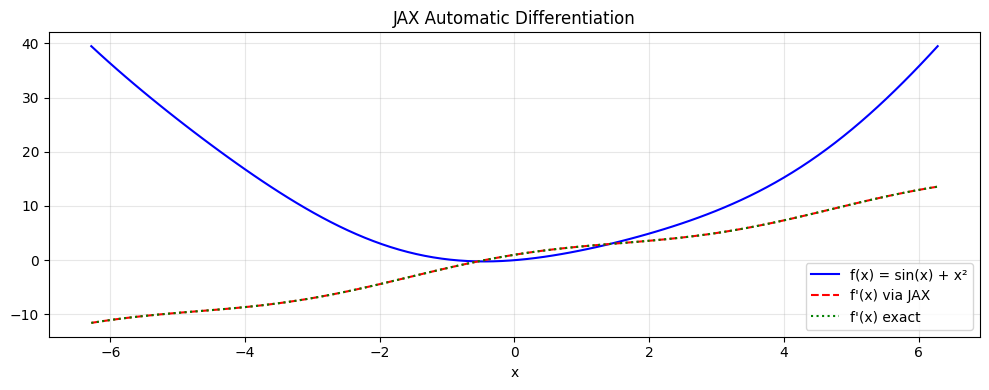

Max error: 0.00e+00


In [7]:
def f(x):
    return jnp.sin(x) + x**2

# Vectorize the gradient: compute f'(x) at many points at once
grad_f = jax.vmap(jax.grad(f))

x = jnp.linspace(-2 * jnp.pi, 2 * jnp.pi, 100)
jax_grads = grad_f(x)
exact_grads = jnp.cos(x) + 2 * x

plt.figure(figsize=(10, 4))
plt.plot(x, f(x), 'b-', label='f(x) = sin(x) + x²')
plt.plot(x, jax_grads, 'r--', label="f'(x) via JAX")
plt.plot(x, exact_grads, 'g:', label="f'(x) exact")
plt.xlabel('x')
plt.legend()
plt.title('JAX Automatic Differentiation')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Max error: {float(jnp.max(jnp.abs(jax_grads - exact_grads))):.2e}")

## ML Example: Gradient Descent Step

The real power of AD — computing gradients of a **loss function** w.r.t. model parameters.

In [8]:
# Linear model: y = a*x + b
# Loss: mean squared error

def mse_loss(params, x, y_true):
    a, b = params
    y_pred = a * x + b
    return jnp.mean((y_true - y_pred)**2)

# Synthetic data: y ≈ 2.5x + 1
x_data = jnp.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_data = jnp.array([3.6, 5.8, 8.65, 10.9, 13.55])

# Start with bad params
params = jnp.array([1.0, 0.0])

grad_loss = jax.grad(mse_loss)
grads = grad_loss(params, x_data, y_data)

print(f"Initial params: a={params[0]:.2f}, b={params[1]:.2f}")
print(f"Initial loss:   {float(mse_loss(params, x_data, y_data)):.4f}")
print(f"Gradients:      ∂L/∂a={grads[0]:.4f}, ∂L/∂b={grads[1]:.4f}")

# One gradient descent step
lr = 0.01
params = params - lr * grads
print(f"\nAfter 1 step:   a={params[0]:.4f}, b={params[1]:.4f}")
print(f"New loss:       {float(mse_loss(params, x_data, y_data)):.4f}")

Initial params: a=1.00, b=0.00
Initial loss:   34.7670
Gradients:      ∂L/∂a=-39.0000, ∂L/∂b=-11.0000

After 1 step:   a=1.3900, b=0.1100
New loss:       20.2896


## Key Takeaways

- `jax.grad(f)` returns a function that computes $f'(x)$ — exact to machine precision
- Works on **composite functions** (chain rule handled automatically)
- Nest `jax.grad()` for higher-order derivatives
- Use `jax.vmap()` to vectorize gradient computation over arrays
- This is the foundation of **backpropagation** in deep learning
- JAX uses **reverse-mode AD** by default, which is efficient for functions with many inputs and a scalar output (like loss functions)